# Postprocess - categories based on category taxonomy graph

https://github.com/openfoodfacts/openfoodfacts-python/blob/develop/docs/handle_taxonomies.md

In [1]:
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy
import networkx as nx
import pandas as pd

## Load Category Taxonomy

Source: https://github.com/openfoodfacts/openfoodfacts-server/blob/main/taxonomies/food/categories.txt

In [2]:
categories: Taxonomy = get_taxonomy("category")
print(f"categories: {len(categories):,}")

categories: 13,404


In [3]:
[c for c in categories.keys() if 'tartiner' in c]

['fr:pates-a-tartiner', 'fr:condiments-a-tartiner']

In [4]:
name = 'en:milk-powders'

categories[name].children
categories[name].parents

[<TaxonomyNode en:dehydrated-beverages>,
 <TaxonomyNode en:dried-products-to-be-rehydrated>,
 <TaxonomyNode en:milks>]

In [5]:
categories['en:candy-chocolate-bars'].synonyms['en']

['Candy chocolate bars', 'Bars covered with chocolate', 'Chocolate bars']

## Read Category Data

In [6]:
df = pd.read_csv("../data/grade_counts.csv", index_col=0)

# add weighted score
df['weighted_score'] = df[['a','b','c','d','e']].apply(
    lambda r: (1*r.a + 2*r.b + 3*r.c + 4*r.d + 5*r.e) / r.sum()
    if r.sum() != 0 else None, axis=1
)

df

,a,b,c,d,e,not-applicable,unknown,total,all_count,not_appl,not_known,entropy,gini,label,weighted_score
categories_tags,,,,,,,,,,,,,,,
en:spring-waters,768,13,1,1,0,5,2,790,6152,0.006345,0.002548,0.150088,0.037668,a,1.022989
en:mineral-waters,673,8,1,1,0,4,1,688,5053,0.005822,0.001462,0.123687,0.028927,a,1.019034
en:natural-mineral-waters,421,1,0,0,0,1,0,423,2691,0.002364,0.000000,0.024081,0.004728,a,1.002370
en:cereal-pastas,300,23,3,6,0,0,35,367,6577,0.000000,0.095368,0.564942,0.178273,a,1.141566
en:durum-wheat-pasta,294,23,3,6,0,0,33,359,6318,0.000000,0.091922,0.572623,0.181283,a,1.144172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
en:beers,0,0,0,0,0,214,0,214,10689,1.000000,0.000000,0.000000,0.000000,not-applicable,NaN
en:chewing-gum,0,0,1,0,0,184,0,185,2775,0.994595,0.000000,-0.000000,0.000000,not-applicable,3.000000
en:salts,0,0,0,0,0,182,0,182,3225,1.000000,0.000000,0.000000,0.000000,not-applicable,NaN


In [7]:
# en:biscuits-and-crackers -> en:Biscuits and crackers
# en:crackers-appetizers -> en:Crackers(Appetizers)
# en:pasteurised-products -> en:Pasteurised products
# en:salads -> does not exist in taxonomy

# en:Spreads <- en: Dairy spreads, Dairy spread
# en:dairy-spreads                      5280
# en:dairy-spread                          6

# en: Dairies <- en: Milks (liquid and powder) <- [en: Milks, Milk as a drink | en: Milk powders]
# en:milks                             16303
# en:milks-liquid-and-powder            4332
# en:milk-powders                        454

# [en: Bars | en: Chocolate candies] <- en: Candy chocolate bars, Bars covered with chocolate, Chocolate bars
# en:bars-covered-with-chocolate        1669
# en:candy-chocolate-bars               1580

# en:Snacks <- en: Sweet snacks, Sugary snacks; fr: Snacks sucrés, sucreries
# en:snacks                              768
# en:snacks-sucres                       705
# en:sweet-snacks                        702

#df.loc['en:yogurt-drinks']
#df[df.index.str.contains('dairy-')]

### Post-Process

some category names cannot be found in the taxonomy. -> Replace with taxonomy name

In [8]:
replace = {
  'en:dairy-spreads': 'en:dairy-spread',
  # 'en:milks-liquid-and-powder': 'en:milks', # obsolete
}

# find and replace categories
for old, new in replace.items():
    if old in df.index:
        df.loc[new] = df.loc[old]
        df.drop(old, inplace=True)
        print(f"Replaced {old} with {new}")

Replaced en:dairy-spreads with en:dairy-spread


## Build Taxonomy Graph

### For 1 or 2 distinct Nutri-Scores (+ parent)

In [9]:
G = nx.DiGraph();
same = []

cats = df[lambda x: x.label.str.len() <= 3].index
print(f"categories with one or two Nutri-Scores: {len(cats):,}")

for cat in cats:
  node = categories[cat]
  if not node:
    print(f"category {cat} ({df.loc[cat].all_count}) not found in taxonomy")
    continue

  # add node/edge to graph
  for parent in node.parents:
    if not parent.id.startswith('en:'):
      print(f"parent {parent.id} of {cat} is not in English")
      continue
    G.add_edge(parent.id[3:], node.id[3:])
  
  # check if node is similar to its parents
  if node.parents and all(p.id in df.index and df.loc[p.id].label == df.loc[cat].label for p in node.parents):
    same.append(cat)

print(f"same: {len(same):,}")

categories with one or two Nutri-Scores: 190
parent fr:pates-a-tartiner of en:hazelnut-spreads is not in English
category en:bars-covered-with-chocolate (1669) not found in taxonomy
category en:milks-liquid-and-powder (4332) not found in taxonomy
parent fr:pates-a-tartiner of en:chocolate-spreads is not in English
category en:snacks-sucres (705) not found in taxonomy
same: 59


In [11]:
print(f"#Nodes: {len(G.nodes):,}")
print(f"#Edges: {len(G.edges):,}")

#Nodes: 258
#Edges: 238


In [12]:
# enrich node labels with additional information
for node_id in G.nodes:
  cat_name = 'en:'+node_id

  if not cat_name in df.index:
    print(f"node '{cat_name}' not found in df")
    continue
  cat = df.loc[cat_name]
  G.nodes[node_id]['label'] = f"{node_id} ({cat.total:,} / {cat.label}[{cat.weighted_score:.2f}] / {cat.entropy:.2f})"

In [13]:
import pydot
from networkx.drawing.nx_pydot import to_pydot
from IPython.display import Image

def display_graph(G):
  # Convert NetworkX graph to a PyDot graph object
  P = to_pydot(G)

  P.set('rankdir', 'LR') # left to right
  P.set('nodesep', '0.1')
  P.set('ranksep', '0.5')

  for node in P.get_nodes():
      name = 'en:'+node.get_name().strip('"')
      # gives nodes a color based on the range of Nutri-Scores (via label length)
      if name in df.index:
        label_len = len(df.loc[name].label)
        color = {1: "moccasin", 3: "tan3"}.get(label_len, "tan4")
      else:
        color = 'grey'
      # give the node a red border if all parents have the same Nutri-Score labels
      if name in same:
        node.set_color('red')
        node.set_fontcolor('purple')
        node.set_penwidth(2)
      
      node.set_shape('box')
      node.set_height(0) # remove top/bottom padding
      node.set_fontsize(10)
      node.set_style("filled")
      node.set_fillcolor(color)

  return P

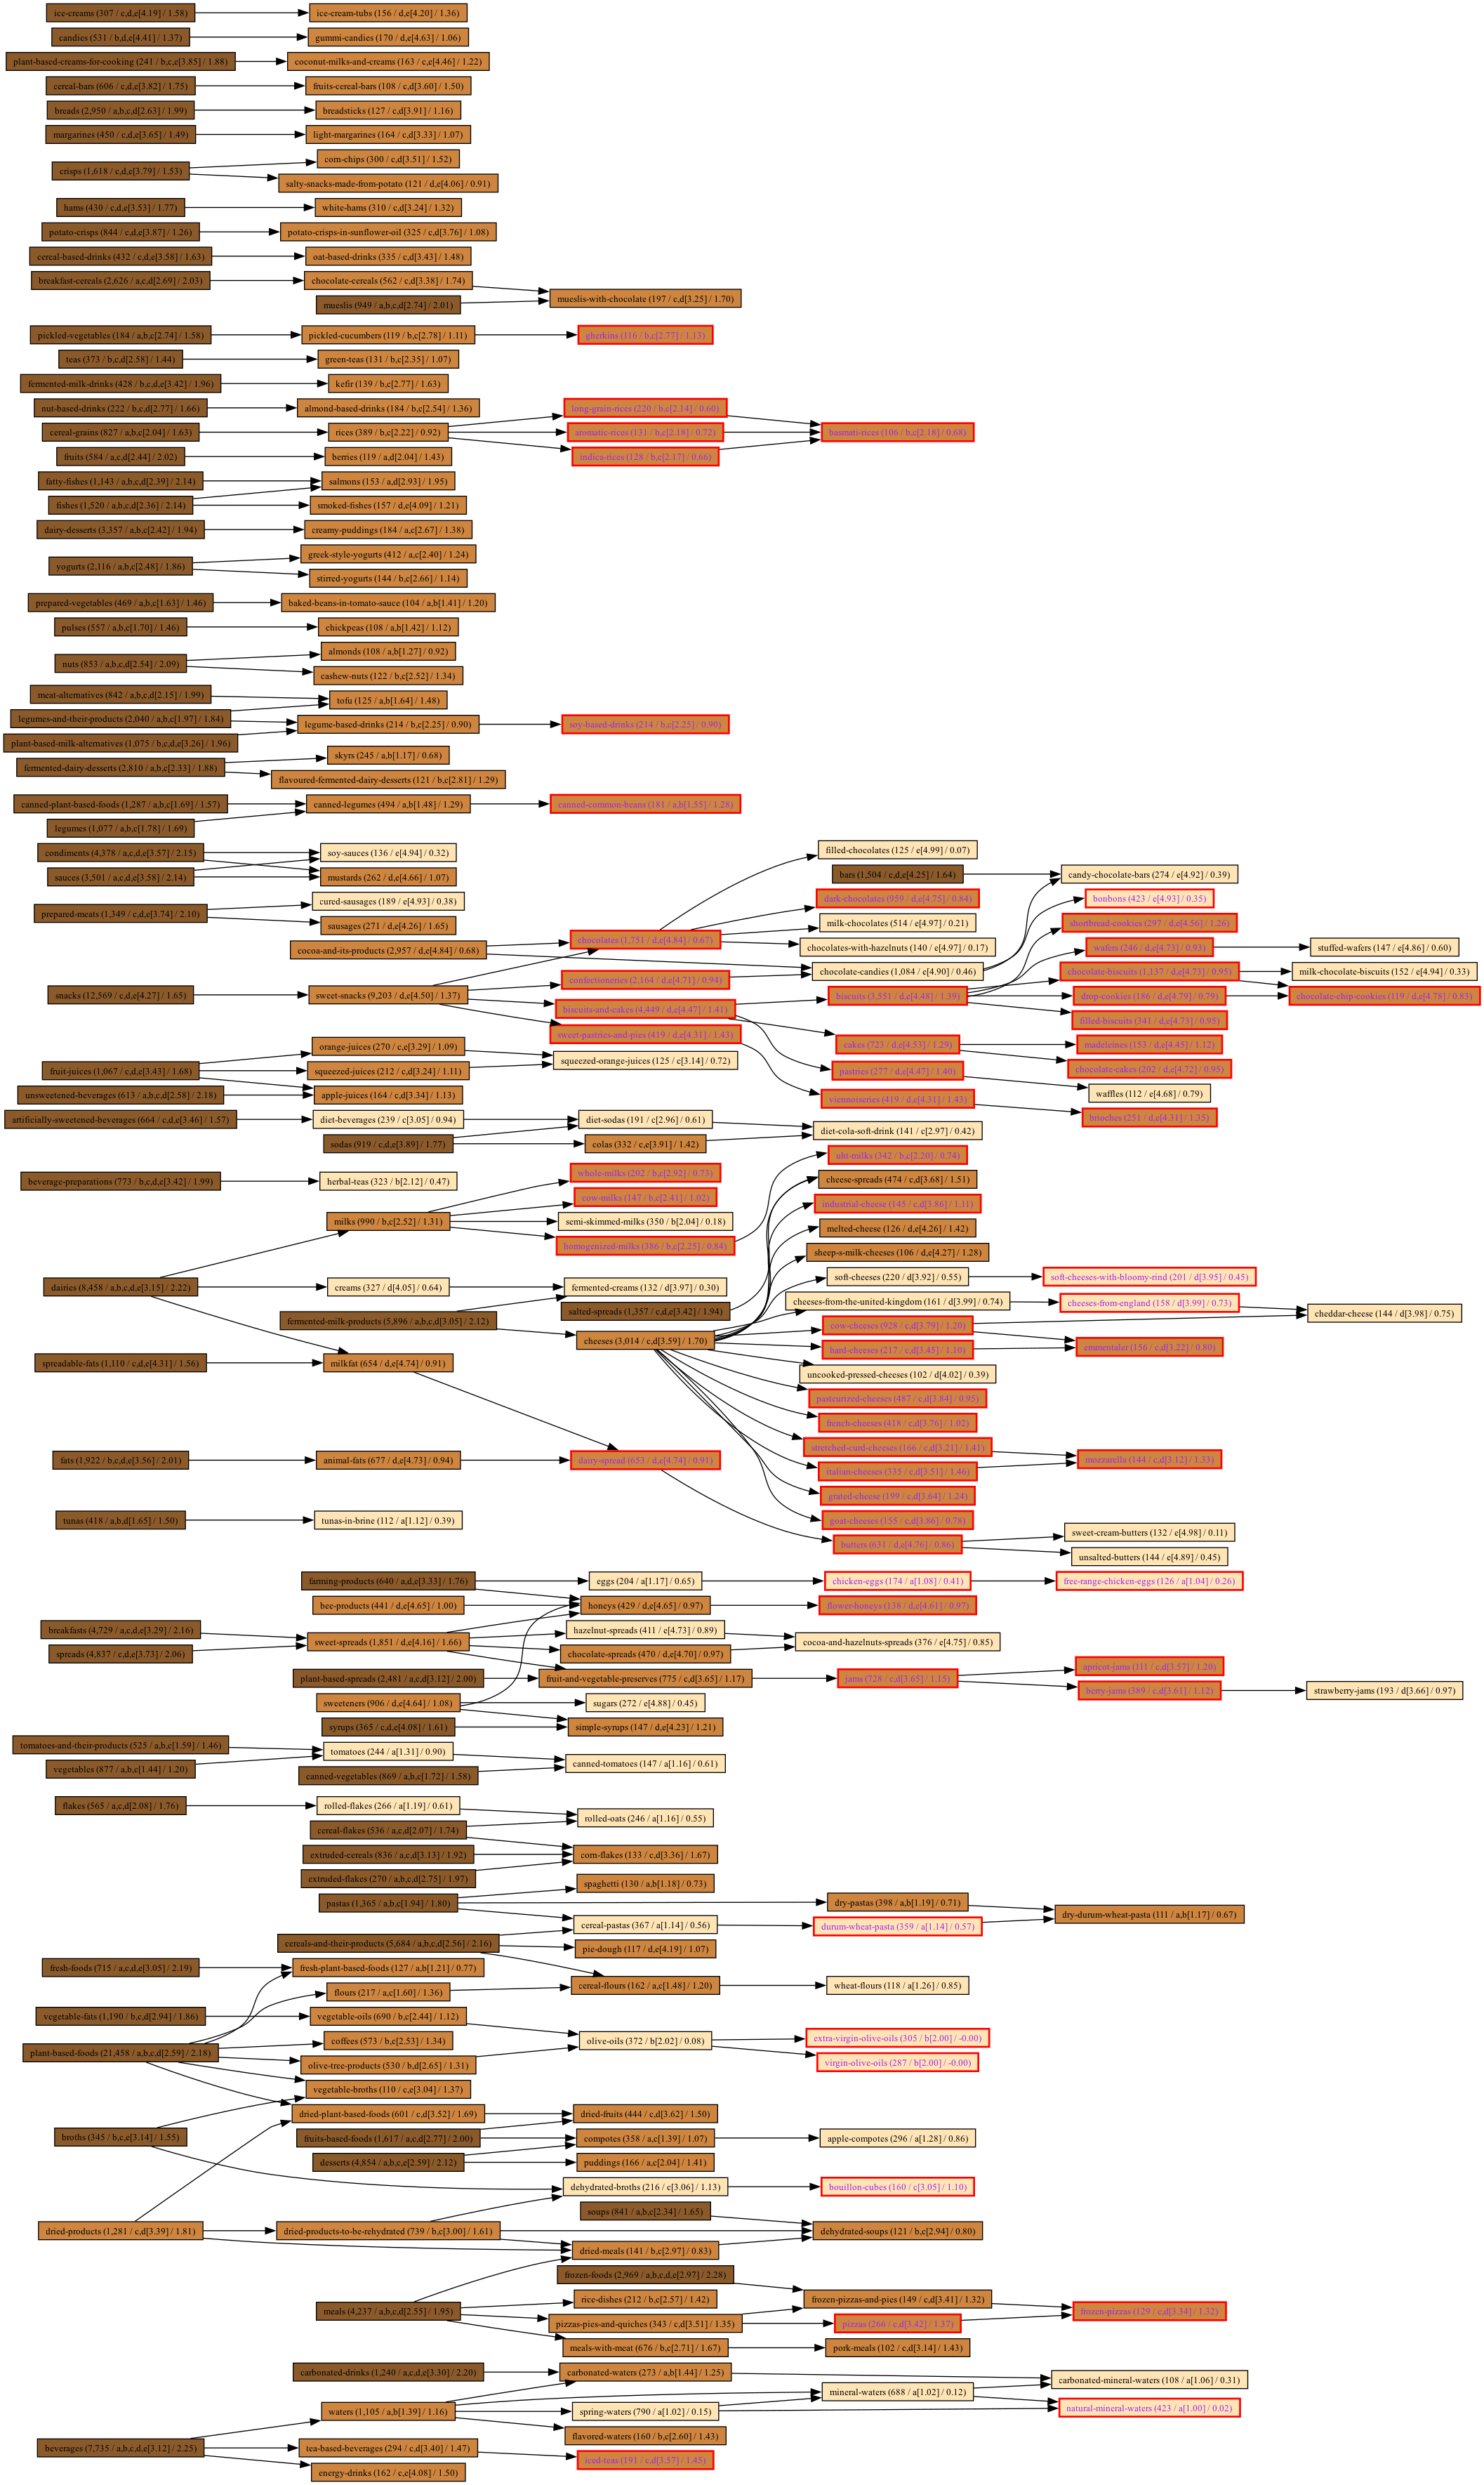

In [14]:
P = display_graph(G)
# P.write_svg('cat-graph.svg')

Image(P.create_png())

## Prune Marked Nodes

rewire parents and children of marked node, then remove the node.

In [15]:
for node in same:
    parents = list(G.predecessors(node[3:]))
    children = list(G.successors(node[3:]))
    
    for p in parents:
        for c in children:
            G.add_edge(p, c)
    G.remove_node(node[3:])

print(f"remaining nodes: {len(G.nodes):,}")

remaining nodes: 199


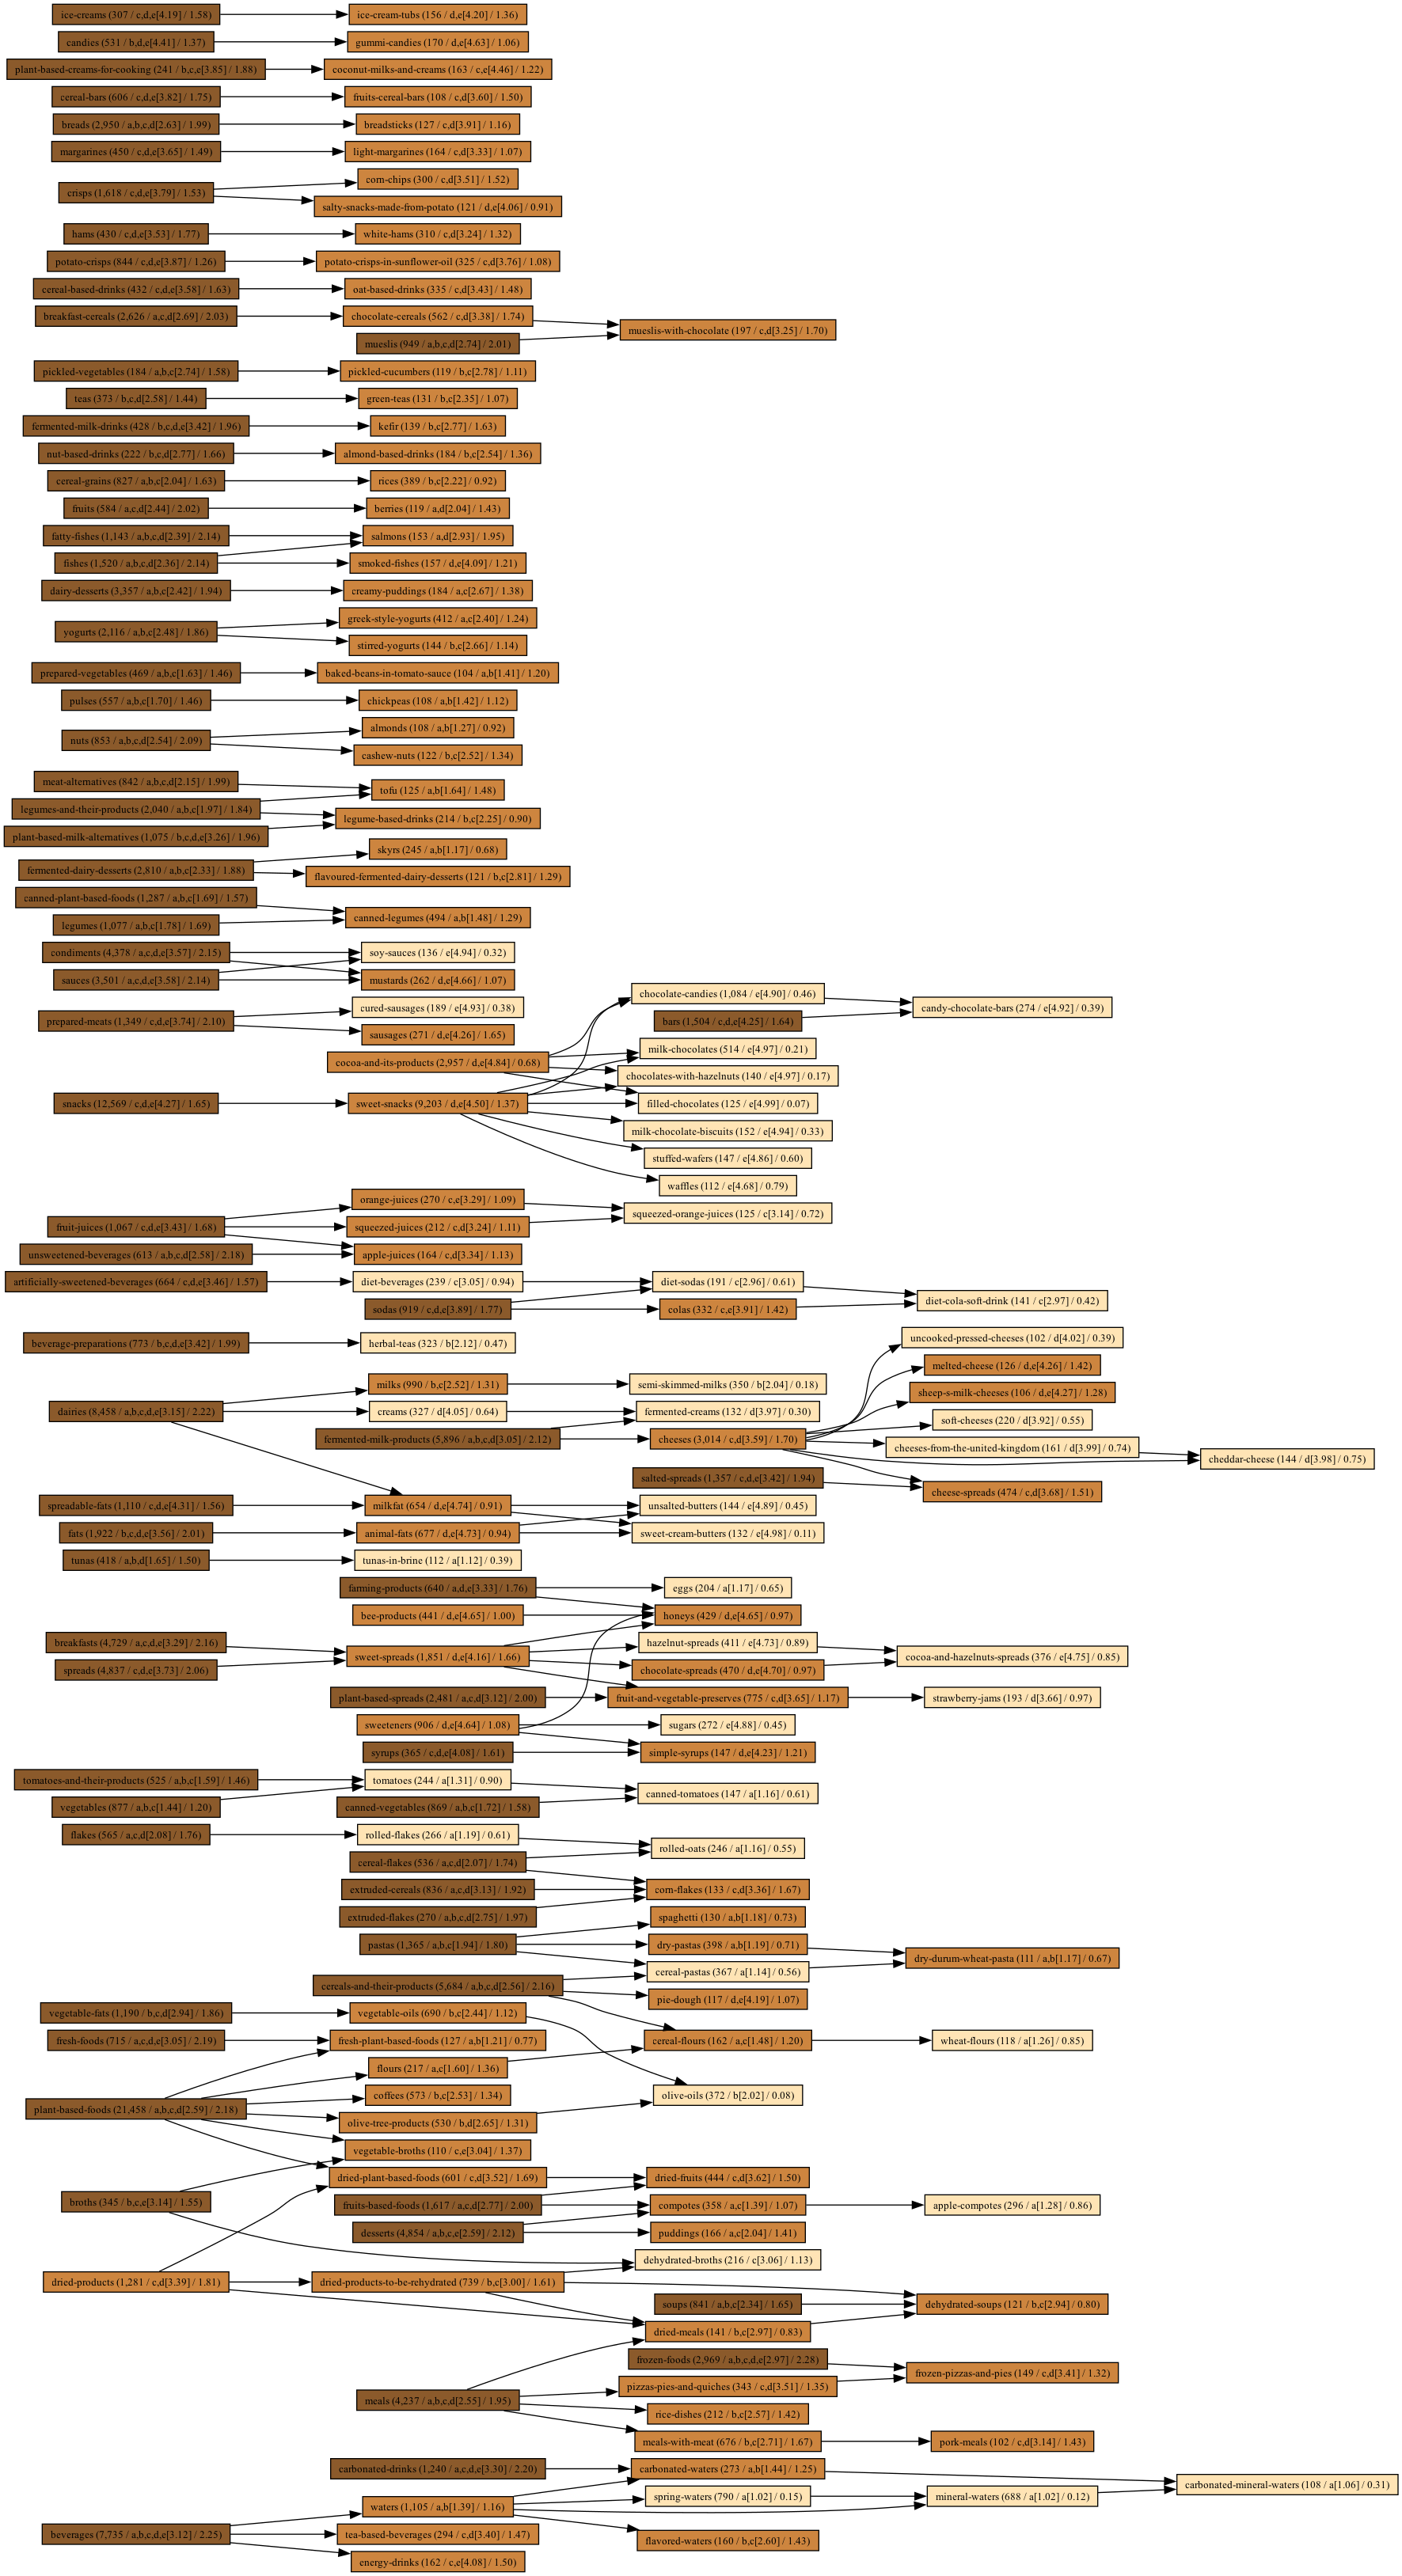

In [16]:
P = display_graph(G)
# P.write_svg('cat-graph.svg')

Image(P.create_png())